# Run 6 — Analyse par sous-groupes de contraste (test set)

**Objectif** : Évaluer la robustesse des 4 méthodes face au faible contraste lésion/fond.

On calcule le contraste $|\Delta|$ par image (différence d'intensité moyenne lésion vs fond en niveaux de gris),
puis on reporte le DSC par bin de contraste pour chaque méthode.

**Données nécessaires** :
- U-Net Final + Baseline : `results_test_evaluation.json` (per-image DSC déjà calculés)
- K-means LAB + CNN Patch : recalculés ici (ou chargés depuis `results_wilcoxon_tests.json` si le run 5 a déjà tourné)

In [1]:
import os, json
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import glob as _glob

# Paths (Onyxia / Kaggle)
_kaggle = _glob.glob('/kaggle/input/*/dataset_ISIC')
_base = _kaggle[0] if _kaggle else 'dataset_ISIC'
BASE = Path(_base)

TEST_IMG_DIR  = BASE / 'ISBI2016_ISIC_Part1_Test_Data'
TEST_MASK_DIR = BASE / 'ISBI2016_ISIC_Part1_Test_GroundTruth'

test_img_paths  = sorted(TEST_IMG_DIR.glob('*.jpg'))
test_mask_paths = sorted(TEST_MASK_DIR.glob('*.png'))
assert len(test_img_paths) == 379
print(f'Test set : {len(test_img_paths)} images')

Test set : 379 images


## 1. Calcul du contraste $|\Delta|$ par image

In [2]:
IMG_SIZE = 256

def load_img(path, size=IMG_SIZE):
    return np.array(Image.open(path).convert('RGB').resize((size, size), Image.BILINEAR), dtype=np.float32)

def load_mask(path, size=IMG_SIZE):
    m = np.array(Image.open(path).convert('L').resize((size, size), Image.NEAREST))
    return (m > 127).astype(np.float32)

# Calcul du contraste pour chaque image du test set
contrast_data = []
for ip, mp in zip(test_img_paths, test_mask_paths):
    img = load_img(ip)  # [0, 255] float32
    gt  = load_mask(mp)
    
    # Luminance ITU-R BT.601
    gray = 0.299 * img[..., 0] + 0.587 * img[..., 1] + 0.114 * img[..., 2]
    
    les_pix = gray[gt == 1]
    bg_pix  = gray[gt == 0]
    
    if les_pix.size > 0 and bg_pix.size > 0:
        delta = float(les_pix.mean() - bg_pix.mean())
    else:
        delta = 0.0
    
    rho = float(gt.mean())
    contrast_data.append({
        'image': ip.stem,
        'delta': delta,
        'abs_delta': abs(delta),
        'rho': rho,
    })

df_contrast = pd.DataFrame(contrast_data)

# Bins de contraste (identiques à l'EDA)
def contrast_class(ad):
    if ad < 20:
        return 'Faible (|Δ|<20)'
    elif ad < 50:
        return 'Moyen (20≤|Δ|<50)'
    else:
        return 'Fort (|Δ|≥50)'

df_contrast['contrast_bin'] = df_contrast['abs_delta'].apply(contrast_class)

print('Distribution du contraste sur le test set :')
print(df_contrast['contrast_bin'].value_counts().sort_index())
print(f'\nContraste moyen : Δ = {df_contrast["delta"].mean():.1f}, |Δ| = {df_contrast["abs_delta"].mean():.1f}')

Distribution du contraste sur le test set :
contrast_bin
Faible (|Δ|<20)       74
Fort (|Δ|≥50)        167
Moyen (20≤|Δ|<50)    138
Name: count, dtype: int64

Contraste moyen : Δ = -47.2, |Δ| = 48.3


## 2. Charger les DSC per-image de chaque méthode

In [3]:
# --- U-Net (depuis results_test_evaluation.json) ---
with open('results_test_evaluation.json') as f:
    test_results = json.load(f)

df_unet_final = pd.DataFrame(test_results['FINAL']['per_image'])[['image', 'dice']]
df_unet_final = df_unet_final.rename(columns={'dice': 'unet_final'})

df_unet_base = pd.DataFrame(test_results['baseline_f64-d4-skip-bce+dice']['per_image'])[['image', 'dice']]
df_unet_base = df_unet_base.rename(columns={'dice': 'unet_baseline'})

print(f'U-Net Final : {len(df_unet_final)} images')
print(f'U-Net Baseline : {len(df_unet_base)} images')

U-Net Final : 379 images
U-Net Baseline : 379 images


In [4]:
# --- K-means LAB + CNN Patch ---
# Option 1 : charger depuis results_wilcoxon_tests.json (si run 5 déjà fait)
# Option 2 : recalculer

wilcoxon_path = 'results_wilcoxon_tests.json'
if os.path.exists(wilcoxon_path):
    print('Chargement depuis results_wilcoxon_tests.json ...')
    with open(wilcoxon_path) as f:
        wilcoxon_data = json.load(f)
    df_wilcoxon = pd.DataFrame(wilcoxon_data['per_image'])
    df_kmeans = df_wilcoxon[['image', 'kmeans_lab']].copy()
    df_cnn    = df_wilcoxon[['image', 'cnn_patch']].copy()
    print(f'  K-means : {len(df_kmeans)} images, CNN Patch : {len(df_cnn)} images')
else:
    print('results_wilcoxon_tests.json non trouvé.')
    print('Recalcul du K-means LAB sur le test set ...')
    
    from skimage import color
    from sklearn.cluster import KMeans
    from scipy.ndimage import label as ndimage_label
    
    def keep_largest_component(mask):
        labeled, n = ndimage_label(mask)
        if n <= 1: return mask
        sizes = [np.sum(labeled == k) for k in range(1, n + 1)]
        return (labeled == np.argmax(sizes) + 1).astype(np.float32)
    
    def dice(y_true, y_pred):
        inter = np.sum(y_true * y_pred)
        denom = np.sum(y_true) + np.sum(y_pred)
        return 2.0 * inter / denom if denom > 0 else 1.0
    
    km_results = []
    for i, (ip, mp) in enumerate(zip(test_img_paths, test_mask_paths)):
        img = load_img(ip) / 255.0
        gt  = load_mask(mp)
        
        img_lab = color.rgb2lab(img)
        h, w, c = img_lab.shape
        pixels = img_lab.reshape(-1, c)
        km = KMeans(n_clusters=2, n_init=10, random_state=42)
        labels = km.fit_predict(pixels)
        cluster_L = [pixels[labels == j, 0].mean() for j in range(2)]
        lesion_cluster = np.argmin(cluster_L)
        mask = (labels == lesion_cluster).reshape(h, w).astype(np.float32)
        mask = keep_largest_component(mask)
        
        km_results.append({'image': ip.stem, 'kmeans_lab': dice(gt, mask)})
        if (i + 1) % 100 == 0:
            print(f'  {i+1}/379')
    
    df_kmeans = pd.DataFrame(km_results)
    print(f'  K-means : {len(df_kmeans)} images, DSC moyen = {df_kmeans["kmeans_lab"].mean():.3f}')
    
    # CNN Patch : nécessite le modèle → on skip si pas dispo
    cnn_model_path = 'models/patch_cnn_p32.keras'
    if os.path.exists(cnn_model_path):
        print('Calcul CNN Patch sur le test set ...')
        os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=0'
        os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0'
        os.environ['TF_USE_CUDNN_BATCHNORM_SPATIAL_PERSISTENT'] = '0'
        import tensorflow as tf
        tf.config.optimizer.set_experimental_options({'disable_meta_optimizer': True})
        
        cnn_model = tf.keras.models.load_model(cnn_model_path)
        PATCH_SIZE, STRIDE = 32, 8
        
        cnn_results = []
        for i, (ip, mp) in enumerate(zip(test_img_paths, test_mask_paths)):
            img = load_img(ip) / 255.0
            gt  = load_mask(mp)
            half = PATCH_SIZE // 2
            ys = list(range(half, IMG_SIZE - half, STRIDE))
            xs = list(range(half, IMG_SIZE - half, STRIDE))
            patches = [img[y-half:y+half, x-half:x+half] for y in ys for x in xs]
            patches = np.array(patches)
            preds = cnn_model.predict(patches, batch_size=256, verbose=0).flatten()
            grid = preds.reshape(len(ys), len(xs))
            prob = np.array(Image.fromarray(grid.astype(np.float32)).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))
            mask = (prob > 0.5).astype(np.float32)
            mask = keep_largest_component(mask)
            cnn_results.append({'image': ip.stem, 'cnn_patch': dice(gt, mask)})
            if (i + 1) % 100 == 0:
                print(f'  {i+1}/379')
        df_cnn = pd.DataFrame(cnn_results)
        print(f'  CNN Patch : {len(df_cnn)} images, DSC moyen = {df_cnn["cnn_patch"].mean():.3f}')
    else:
        print(f'  [!] Modèle CNN non trouvé ({cnn_model_path}), CNN Patch exclu de l\'analyse.')
        df_cnn = None

Chargement depuis results_wilcoxon_tests.json ...
  K-means : 379 images, CNN Patch : 379 images


## 3. Fusion et analyse par sous-groupes de contraste

In [5]:
# Fusionner tout
df = df_contrast.merge(df_unet_final, on='image')\
                .merge(df_unet_base, on='image')\
                .merge(df_kmeans, on='image')

methods = ['kmeans_lab', 'unet_baseline', 'unet_final']
method_labels = {'kmeans_lab': 'K-means LAB', 'unet_baseline': 'U-Net Baseline',
                 'unet_final': 'U-Net Final'}

if df_cnn is not None:
    df = df.merge(df_cnn, on='image')
    methods.insert(1, 'cnn_patch')
    method_labels['cnn_patch'] = 'CNN Patch'

assert len(df) == 379, f'Alignement échoué : {len(df)} images'
print(f'Fusion OK : {len(df)} images, {len(methods)} méthodes')

Fusion OK : 379 images, 4 méthodes


In [6]:
# Tableau par sous-groupes de contraste
bins_order = ['Faible (|Δ|<20)', 'Moyen (20≤|Δ|<50)', 'Fort (|Δ|≥50)']

print('=' * 90)
print('DSC PAR SOUS-GROUPE DE CONTRASTE — TEST SET ISBI 2016 (n=379)')
print('=' * 90)

header = f'{"Sous-groupe":<25} {"n":>4}'
for m in methods:
    header += f'  {method_labels[m]:>16}'
print(header)
print('-' * 90)

rows_for_latex = []
for bin_name in bins_order:
    sub = df[df['contrast_bin'] == bin_name]
    n = len(sub)
    row = f'{bin_name:<25} {n:>4}'
    latex_row = {'bin': bin_name, 'n': n}
    for m in methods:
        mean_dsc = sub[m].mean()
        std_dsc  = sub[m].std()
        row += f'  {mean_dsc:>7.3f} ± {std_dsc:.3f}'
        latex_row[m] = (mean_dsc, std_dsc)
    print(row)
    rows_for_latex.append(latex_row)

# Global
print('-' * 90)
row = f'{"Global":<25} {len(df):>4}'
for m in methods:
    row += f'  {df[m].mean():>7.3f} ± {df[m].std():.3f}'
print(row)

DSC PAR SOUS-GROUPE DE CONTRASTE — TEST SET ISBI 2016 (n=379)
Sous-groupe                  n       K-means LAB         CNN Patch    U-Net Baseline       U-Net Final
------------------------------------------------------------------------------------------
Faible (|Δ|<20)             74    0.320 ± 0.343    0.696 ± 0.222    0.781 ± 0.187    0.824 ± 0.168
Moyen (20≤|Δ|<50)          138    0.596 ± 0.334    0.776 ± 0.173    0.865 ± 0.102    0.872 ± 0.122
Fort (|Δ|≥50)              167    0.831 ± 0.201    0.776 ± 0.146    0.899 ± 0.137    0.915 ± 0.106
------------------------------------------------------------------------------------------
Global                     379    0.646 ± 0.343    0.760 ± 0.175    0.863 ± 0.143    0.882 ± 0.130


In [7]:
# Gain du U-Net vs K-means par bin
print('\n' + '=' * 70)
print('GAIN U-NET FINAL vs K-MEANS LAB PAR CONTRASTE')
print('=' * 70)
for bin_name in bins_order:
    sub = df[df['contrast_bin'] == bin_name]
    km_dsc = sub['kmeans_lab'].mean()
    un_dsc = sub['unet_final'].mean()
    delta = un_dsc - km_dsc
    print(f'  {bin_name:<25} K-means={km_dsc:.3f}  U-Net={un_dsc:.3f}  Δ={delta:+.3f}')


GAIN U-NET FINAL vs K-MEANS LAB PAR CONTRASTE
  Faible (|Δ|<20)           K-means=0.320  U-Net=0.824  Δ=+0.505
  Moyen (20≤|Δ|<50)         K-means=0.596  U-Net=0.872  Δ=+0.277
  Fort (|Δ|≥50)             K-means=0.831  U-Net=0.915  Δ=+0.084


## 4. Visualisation

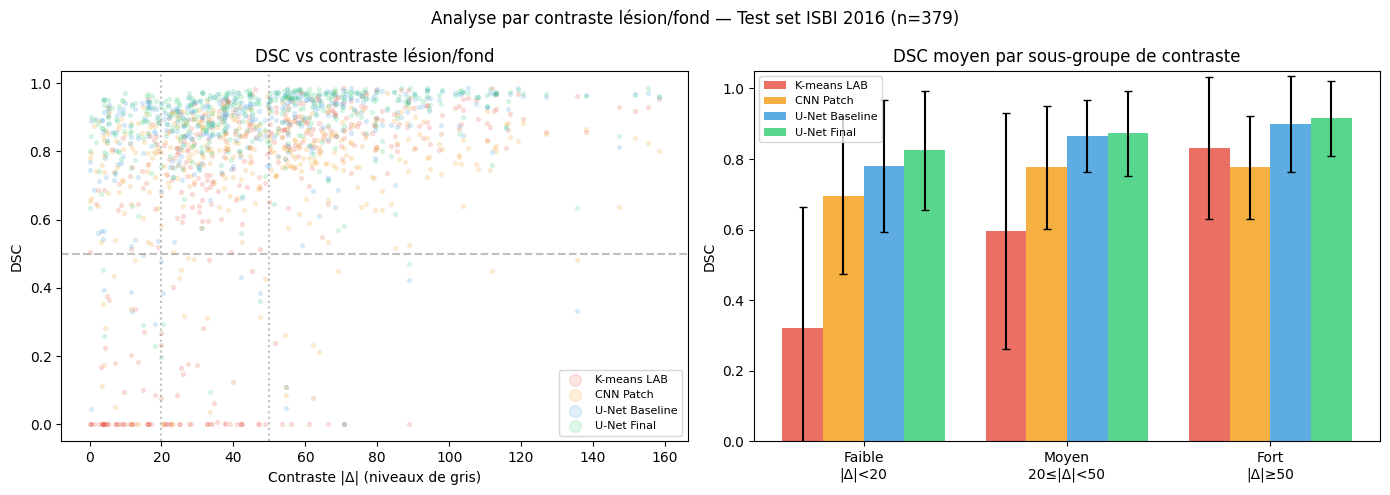

Figure sauvegardée : figures/fig_contrast_subgroups.pdf


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Scatter : DSC vs |Δ| pour chaque méthode ---
ax = axes[0]
colors = {'kmeans_lab': '#e74c3c', 'cnn_patch': '#f39c12', 
           'unet_baseline': '#3498db', 'unet_final': '#2ecc71'}
for m in methods:
    ax.scatter(df['abs_delta'], df[m], alpha=0.15, s=8, color=colors[m], label=method_labels[m])

ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(20, color='gray', linestyle=':', alpha=0.5)
ax.axvline(50, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Contraste |Δ| (niveaux de gris)')
ax.set_ylabel('DSC')
ax.set_title('DSC vs contraste lésion/fond')
ax.legend(fontsize=8, markerscale=3)

# --- Barplot groupé par bin de contraste ---
ax = axes[1]
x = np.arange(len(bins_order))
width = 0.8 / len(methods)

for i, m in enumerate(methods):
    means = [df[df['contrast_bin'] == b][m].mean() for b in bins_order]
    stds  = [df[df['contrast_bin'] == b][m].std() for b in bins_order]
    ax.bar(x + i * width, means, width, yerr=stds, label=method_labels[m],
           color=colors[m], alpha=0.8, capsize=3)

ax.set_xticks(x + width * (len(methods) - 1) / 2)
ax.set_xticklabels(['Faible\n|Δ|<20', 'Moyen\n20≤|Δ|<50', 'Fort\n|Δ|≥50'])
ax.set_ylabel('DSC')
ax.set_title('DSC moyen par sous-groupe de contraste')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)

plt.suptitle('Analyse par contraste lésion/fond — Test set ISBI 2016 (n=379)', fontsize=12)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/fig_contrast_subgroups.pdf', bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/fig_contrast_subgroups.pdf')

## 5. Sauvegarde

In [9]:
output = {
    'test_set_size': 379,
    'contrast_bins': {},
    'global': {},
}

for bin_name in bins_order:
    sub = df[df['contrast_bin'] == bin_name]
    output['contrast_bins'][bin_name] = {
        'n': len(sub),
        **{m: {'mean': round(float(sub[m].mean()), 4), 
               'std': round(float(sub[m].std()), 4)}
           for m in methods}
    }

for m in methods:
    output['global'][m] = {
        'mean': round(float(df[m].mean()), 4),
        'std': round(float(df[m].std()), 4),
    }

with open('results_contrast_subgroups.json', 'w') as f:
    json.dump(output, f, indent=2)

print('Résultats sauvegardés : results_contrast_subgroups.json')

Résultats sauvegardés : results_contrast_subgroups.json


In [10]:
# Tableau LaTeX prêt à copier
print('\n' + '=' * 80)
print('VALEURS POUR LE MÉMOIRE')
print('=' * 80)
for r in rows_for_latex:
    line = f"{r['bin']:<25} n={r['n']:>3}"
    for m in methods:
        mean, std = r[m]
        line += f"  {mean:.3f}"
    print(line)


VALEURS POUR LE MÉMOIRE
Faible (|Δ|<20)           n= 74  0.320  0.696  0.781  0.824
Moyen (20≤|Δ|<50)         n=138  0.596  0.776  0.865  0.872
Fort (|Δ|≥50)             n=167  0.831  0.776  0.899  0.915
